Proyecto 2: Clasificación de texto: Spooky Author Identification

Samira Vergara 

Problema: Dada una oración (que es el fragmento de un libro), indentificar a cuál de los 3 autores del dataset pertenece

- EAP: Edgar Allan Poe
- HLP: H.P. Lovecraft
- MWS: Mary Wollstonecraft Shelley

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#librerías de Machine learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#Librerías para deep learning (redes neuronales)
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModel

#Verifico si tengo tarjeta gráfica para que esto no tarde una eternidad
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Voy a usar:", dispositivo)

Voy a usar: cuda


In [12]:
datos_originales = pd.read_csv("train.csv")
datos_originales.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


In [ ]:

datos_originales.info()
datos_originales.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19579 entries, 0 to 19578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19579 non-null  object
 1   text    19579 non-null  object
 2   author  19579 non-null  object
dtypes: object(3)
memory usage: 459.0+ KB


id        0
text      0
author    0
dtype: int64

In [14]:
#Feature engineering y selección de variables 
#Las redes neuronales no leen letras, leen números. Así que usaré map para traducir los autores a 0, 1 y 2.
datos_originales["autor_num"] = datos_originales["author"].map({"EAP": 0, "HPL": 1, "MWS": 2})

#Hay datos que en verdad no sirven para nada, como el "id" de la frase, así que voy a hacer una limpieza previa
datos = datos_originales.drop(columns=["id"], errors="ignore")

#Voy a crear un par de columnas nuevas contando cuántas palabras y letras tiene cada frase para ver si sirve de algo
datos["n_caracteres"] = datos["text"].str.len()
datos["n_palabras"] = datos["text"].str.split().apply(len)

print(datos["author"].value_counts())

author
EAP    7900
MWS    6044
HPL    5635
Name: count, dtype: int64


C:\Users\samir\AppData\Local\Temp\ipykernel_12948\2984114535.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x="author", palette="Set2")


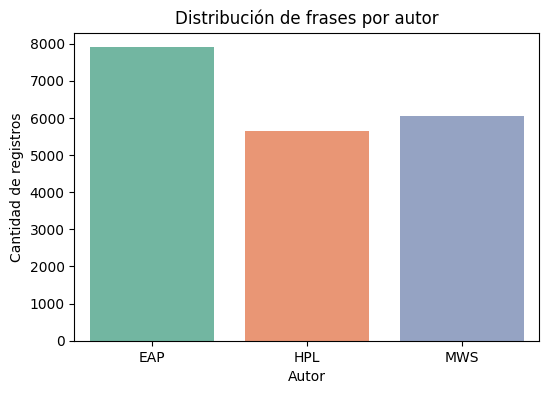

In [15]:
#Visualización

plt.figure(figsize=(6, 4))

#Dibujar un gráfico de barras contando las frases por autor
sns.countplot(data=datos, x="author", palette="Set2")
plt.title("Distribución de frases por autor")
plt.xlabel("Autor")
plt.ylabel("Cantidad de registros")
plt.show()

Podemos ver que el Dataset está balanceado entre las 3 clases a diferencia del practico de clasificación de texto, así que podemos usar acurracy como métrica principal, complementada con F1-macro

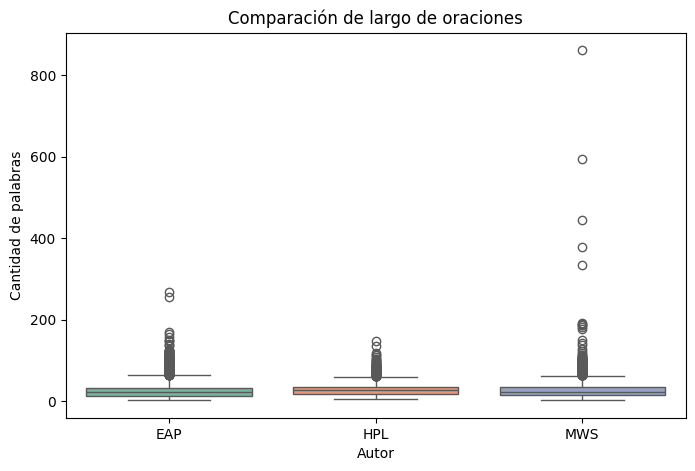

In [16]:
#boxplot para ver si algún autor escribe frases más largas
plt.figure(figsize=(8, 5))
sns.boxplot(data=datos, x="author", y="n_palabras", hue="author", palette="Set2", legend=False)
plt.title("Comparación de largo de oraciones")
plt.ylabel("Cantidad de palabras")
plt.xlabel("Autor")
plt.show()

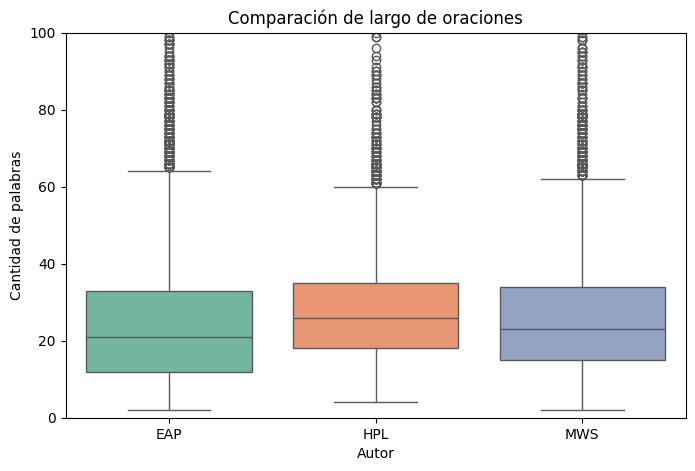

In [17]:
#boxplot para ver si algún autor escribe frases más largas
plt.figure(figsize=(8, 5))
sns.boxplot(data=datos, x="author", y="n_palabras", hue="author", palette="Set2", legend=False)
plt.title("Comparación de largo de oraciones")
plt.ylabel("Cantidad de palabras")
plt.xlabel("Autor")
#Corto el gráfico en 100 palabras para que los valores extremos no aplasten la caja
plt.ylim(0, 100) 
plt.show()

Se puede apreciar que H.P. Lovecraft (HPL) está un poco más arriba, lo que significa que en su estilo normal suele escribir oraciones mucho más largas, sin embargo, cuando veo los máximos Mary Shelley (MWS) es la que escribe oraciones atípicas más largas (llegando a pasar las 800 palabras). Esto significa que la longitud de escritura también sirve para diferenciarlos y no solamente que palabras usan.

In [18]:
#Primero separo las pistas (textos) de las respuestas (autor_num) (como hicimos en el práctico de spam)
X = datos["text"].tolist()
y = datos["autor_num"].values

#Corto la tabla para tener escenarios para estudiar y escenarios ocultos para la prueba final
#Aquí uso train_test_split porque en textos es mejor que cortar con iloc, para que queden mezclados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Tenemos", len(X_train), "escenarios para estudiar")
print("y", len(X_test), "escenarios ocultos para la prueba final")

Tenemos 15663 escenarios para estudiar
y 3916 escenarios ocultos para la prueba final


,Palabra,Información aportada
3540,raymond,0.015402
2646,love,0.010191
3204,perdita,0.009529
78,adrian,0.008539
3065,old,0.007850
2111,heart,0.007424
1696,father,0.007025
2233,idris,0.007019
4264,street,0.005662
2827,misery,0.005487


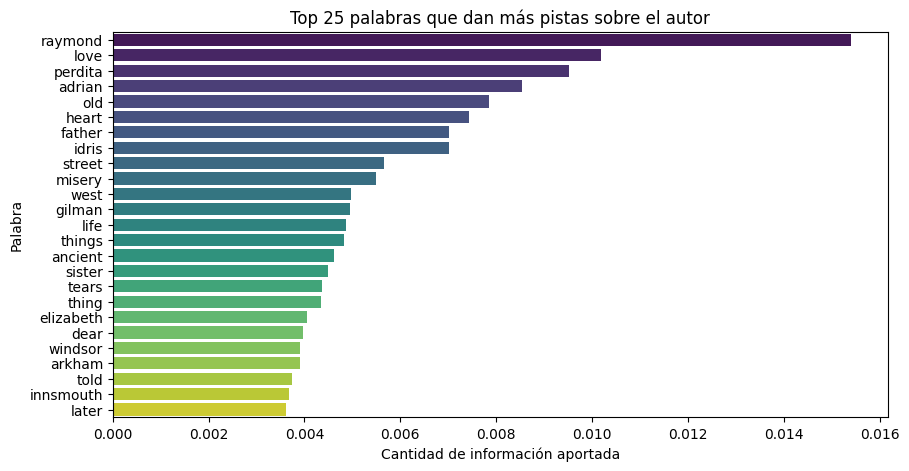

In [19]:
# Feature Selection (información mutua)
# Como mutual_info no entiende texto, primero transformo las palabras a frecuencias (Bag of words)
vectorizador_conteo = CountVectorizer(stop_words="english", max_features=5000)

# el vectorizador "aprende" las palabras con los datos de estudio
X_train_conteo = vectorizador_conteo.fit_transform(X_train)

# calcular la importancia de cada palabra (feature)
puntajes_informacion = mutual_info_classif(X_train_conteo, y_train, random_state=42)

# tabla para visualizar el ranking de importancia
tabla_importancia = pd.DataFrame({
    "Palabra": vectorizador_conteo.get_feature_names_out(),
    "Información aportada": puntajes_informacion
}).sort_values(by="Información aportada", ascending=False)

# mostrar la tablita de texto
display(tabla_importancia.head(15))

#GRÁFICO DE BARRAS

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tabla_importancia.head(25), 
    x="Información aportada", 
    y="Palabra",
    hue="Palabra", 
    palette="viridis", #colores bonitos
    legend=False
)

plt.title("Top 25 palabras que dan más pistas sobre el autor")
plt.xlabel("Cantidad de información aportada")
plt.ylabel("Palabra")

plt.show()

Aquí puedo ver que lo que más se repite no es un estilo de escritura sino que son nombres de los personajes de los libros, esto podría dificultar a mi modelo ya que puede que no esté "aprendiendo" una forma de escribir sino que simplemente esté memorizando que nombres aparecen en qué libros porque si dice "Arkham" es obvio que se refiere a Lovecraft sin importar el estilo de la frase. 

In [ ]:
# Usando Naive Bayes
#Usamos Bag of words (bow)(Countvectorizer) tal como se vio en la Clase 9 y el práctico
bow = CountVectorizer(stop_words="english", max_features=10000)

# El traductor aprende las palabras y transforma los textos a números
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# Llamo al modelo
modelo_nb = MultinomialNB()

# Validación cruzada (control de overfitting)
# Toma 5 pruebas distintas a los datos de estudio
notas_cv_nb = cross_val_score(modelo_nb, X_train_bow, y_train, cv=5)
print(f"Validación cruzada (5 pruebas): {notas_cv_nb.mean()*100:.2f}% de exactitud promedio")

# Lo hago estudiar los datos definitivos
modelo_nb.fit(X_train_bow, y_train)

# Testeo, le pido que adivine el autor de los datos ocultos
predicciones_nb = modelo_nb.predict(X_test_bow)

# Comparo sus adivinanzas con las respuestas reales
precision_nb = accuracy_score(y_test, predicciones_nb)
print(f"El modelo predijo el autor con un {precision_nb * 100:.2f}% de exactitud.\n")

# Reporte completo de métricas
print("\nReporte de clasificación detallado:")
print(classification_report(y_test, predicciones_nb, target_names=["EAP", "HPL", "MWS"]))

Validación cruzada (5 pruebas): 81.41% de exactitud promedio
El modelo predijo el autor con un 82.25% de exactitud.


Reporte de clasificación detallado:
              precision    recall  f1-score   support

         EAP       0.84      0.81      0.82      1580
         HPL       0.83      0.82      0.83      1127
         MWS       0.79      0.84      0.82      1209

    accuracy                           0.82      3916
   macro avg       0.82      0.82      0.82      3916
weighted avg       0.82      0.82      0.82      3916



<Figure size 600x400 with 0 Axes>

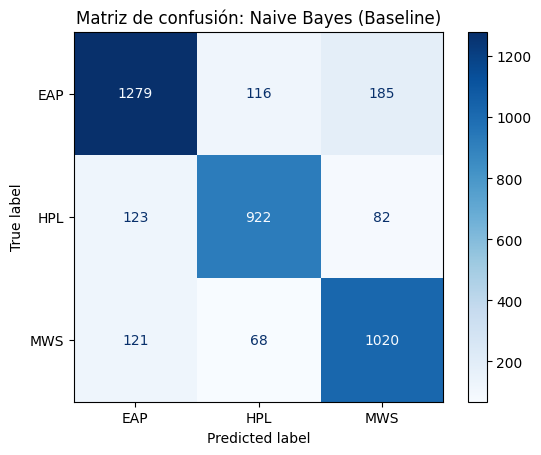

In [21]:
#Matriz de confusión con los aciertos y errores
matriz_nb = confusion_matrix(y_test, predicciones_nb)
grafico_nb = ConfusionMatrixDisplay(confusion_matrix=matriz_nb, display_labels=["EAP", "HPL", "MWS"])

plt.figure(figsize=(6,4))
grafico_nb.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión: Naive Bayes (Baseline)")
plt.show()

In [ ]:
# Armo la clase para "empaquetar" e ir guardando el texto en bruto
class DatasetAutores(Dataset):
    def __init__(self, textos, etiquetas):
        self.textos = textos
        self.etiquetas = etiquetas

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        # Retorna el texto puro y la respuesta (0, 1 o 2)
        return self.textos[idx], int(self.etiquetas[idx])

# La función empacadora
def collate_fn(batch):
    textos, etiquetas = zip(*batch)
    return list(textos), torch.tensor(etiquetas, dtype=torch.long)

# Separar un 10% del entrenamiento para usarlo como validación
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

tamaño_batch = 32

# Mete todo a los dataLoaders usando el texto original
train_loader = DataLoader(
    DatasetAutores(X_train_dl, y_train_dl),
    batch_size=tamaño_batch,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    DatasetAutores(X_val_dl, y_val_dl),
    batch_size=tamaño_batch,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    DatasetAutores(X_test, y_test),
    batch_size=tamaño_batch,
    shuffle=False,
    collate_fn=collate_fn,
)

print(f"Lotes de estudio: {len(train_loader)}, Lotes de validación: {len(val_loader)}")

Lotes de estudio: 441, Lotes de validación: 49


In [24]:
#La red neuronal 
import torch.nn as nn

class ClasificadorTexto(nn.Module):
    def __init__(self, nombre_modelo, n_clases):
        super().__init__()
        
        # El diccionario y el modelo pre-entrenado se guardan aquí adentro
        self.tokenizador = AutoTokenizer.from_pretrained(nombre_modelo)
        self.encoder = AutoModel.from_pretrained(nombre_modelo)

        # Congelar el conocimiento previo (Transfer Learning)
        for p in self.encoder.parameters():
            p.requires_grad = False
            
        self.dropout = nn.Dropout(0.5)
        
        # Capa final para los 3 autores
        self.clasificador = nn.Linear(
            self.encoder.config.hidden_size,
            n_clases
        )

    def forward(self, textos):
        #Traduce el texto a números
        entradas = self.tokenizador(
            textos,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )
        
        #Mueve los números a la tarjeta gráfica (GPU)
        entradas = {k: v.to(self.clasificador.weight.device) for k, v in entradas.items()}

        # Pasa por BERT sin gastar memoria extra
        with torch.no_grad():
            salidas = self.encoder(**entradas)

        # Saca el resumen matemático de la frase
        oculto = salidas.last_hidden_state
        mascara = entradas["attention_mask"].unsqueeze(-1)
        embedding = (oculto * mascara).sum(1) / mascara.sum(1)
        
        #Capa de olvido (dropout) y predicción final
        embedding = self.dropout(embedding)
        return self.clasificador(embedding)

# Construir el modelo y mandarlo a la gráfica
MODELO_BASE = "bert-base-uncased"
modelo_bert = ClasificadorTexto(MODELO_BASE, n_clases=3).to(dispositivo)

# Ajusto las tuercas
criterion = CrossEntropyLoss()
lr = 1e-3
weight_decay = 0.2
optimizer = AdamW(modelo_bert.parameters(), lr=lr, weight_decay=weight_decay)

c:\Users\samir\anaconda3\envs\dron\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [27]:
#El Loop de Entrenamiento
# Función para correr una sola época
def correr_epoca(loader, entrenar=True):
    modelo_bert.train(entrenar)
    perdida_total, correctos, n = 0.0, 0, 0

    for textos, etiquetas in loader:
        etiquetas = etiquetas.to(dispositivo) # Mover respuestas a la GPU

        if entrenar: # Backpropagation
            optimizer.zero_grad() # Inicializar en 0 los gradientes

        with torch.set_grad_enabled(entrenar):
            # Evaluar y calcular loss
            logits = modelo_bert(textos)
            loss = criterion(logits, etiquetas)

        if entrenar: # Aprender del error
            loss.backward()
            optimizer.step()

        perdida_total += loss.item() * etiquetas.size(0)
        correctos += (logits.argmax(dim=1) == etiquetas).sum().item()
        n += etiquetas.size(0)

    return perdida_total / n, correctos / n


In [28]:
EPOCAS = 15
PACIENCIA = 3

# Usar un diccionario para guardar el historial
historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

mejor_perdida_val = float("inf") 
mejor_estado = None
contador_paciencia = 0

for epoca in range(1, EPOCAS + 1):
    perdida_train, acc_train = correr_epoca(train_loader, entrenar=True)
    perdida_val, acc_val = correr_epoca(val_loader, entrenar=False)

    historial["train_loss"].append(perdida_train)
    historial["train_acc"].append(acc_train)
    historial["val_loss"].append(perdida_val)
    historial["val_acc"].append(acc_val)

    print(
        f"epoch {epoca}/{EPOCAS} | "
        f"train loss {perdida_train:.4f} acc {acc_train:.3f} | "
        f"val loss {perdida_val:.4f} acc {acc_val:.3f}"
    )

    if perdida_val < mejor_perdida_val:
        mejor_perdida_val = perdida_val
        # Guardado en RAM (instantáneo)
        mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo_bert.state_dict().items()}
        contador_paciencia = 0
    else:
        contador_paciencia += 1
        if contador_paciencia >= PACIENCIA:
            print(f"Early stopping en epoch {epoca} (mejor val loss: {mejor_perdida_val:.4f})")
            break

if mejor_estado is not None:
    modelo_bert.load_state_dict(mejor_estado)
    print(f"Modelo restaurado al mejor checkpoint (val loss {mejor_perdida_val:.4f})")

epoch 1/15 | train loss 0.7857 acc 0.665 | val loss 0.6448 acc 0.739
epoch 2/15 | train loss 0.6824 acc 0.717 | val loss 0.6031 acc 0.770
epoch 3/15 | train loss 0.6668 acc 0.719 | val loss 0.5883 acc 0.764
epoch 4/15 | train loss 0.6604 acc 0.723 | val loss 0.5816 acc 0.772
epoch 5/15 | train loss 0.6577 acc 0.722 | val loss 0.5832 acc 0.768
epoch 6/15 | train loss 0.6554 acc 0.723 | val loss 0.5793 acc 0.772
epoch 7/15 | train loss 0.6581 acc 0.726 | val loss 0.5806 acc 0.770
epoch 8/15 | train loss 0.6612 acc 0.722 | val loss 0.5695 acc 0.785
epoch 9/15 | train loss 0.6523 acc 0.730 | val loss 0.5697 acc 0.774
epoch 10/15 | train loss 0.6498 acc 0.731 | val loss 0.5697 acc 0.777
epoch 11/15 | train loss 0.6511 acc 0.728 | val loss 0.5796 acc 0.757
Early stopping en epoch 11 (mejor val loss: 0.5695)
Modelo restaurado al mejor checkpoint (val loss 0.5695)


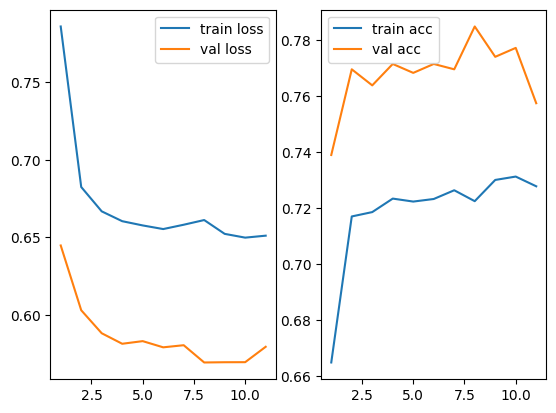

In [29]:
#visualización de resultados
plt.subplot(1, 2, 1)
sns.lineplot(y=historial["train_loss"], x=range(1, len(historial["train_loss"]) + 1), label="train loss")
sns.lineplot(y=historial["val_loss"], x=range(1, len(historial["val_loss"]) + 1), label="val loss")
plt.subplot(1, 2, 2)
sns.lineplot(y=historial["train_acc"], x=range(1, len(historial["train_acc"]) + 1), label="train acc")
sns.lineplot(y=historial["val_acc"], x=range(1, len(historial["val_acc"]) + 1), label="val acc")
plt.show()

Accuracy (Test): 0.7701736465781409
F1-macro (Test): 0.7688515555323806

Reporte de clasificación detallado:
              precision    recall  f1-score   support

         EAP       0.77      0.79      0.78      1580
         HPL       0.77      0.76      0.76      1127
         MWS       0.77      0.75      0.76      1209

    accuracy                           0.77      3916
   macro avg       0.77      0.77      0.77      3916
weighted avg       0.77      0.77      0.77      3916



<Figure size 600x400 with 0 Axes>

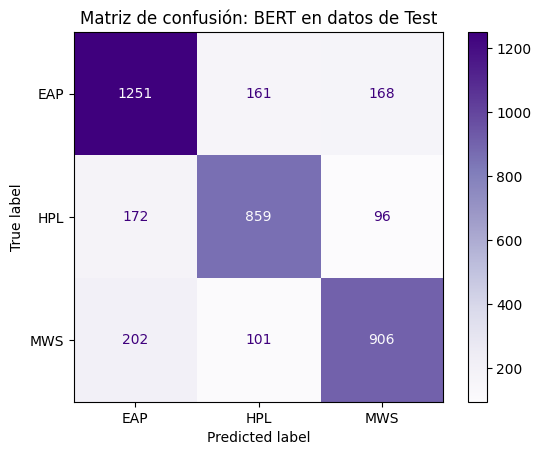

In [30]:
from sklearn.metrics import f1_score

# Nombres de los 3 autores para que el reporte se entienda
nombres_clases = ["EAP", "HPL", "MWS"]

# función para el examen final
def evaluar_con_predicciones(loader):
    modelo_bert.eval() # Modo evaluación
    todas_pred, todas_etiquetas = [], []
    
    with torch.no_grad(): # No gastar memoria aprendiendo
        for textos, etiquetas in loader:
            etiquetas = etiquetas.to(dispositivo)
            
            # Pedirle al modelo que adivine
            logits = modelo_bert(textos)
            pred = logits.argmax(dim=1)
            
            # Guardar la adivinanza y la respuesta real
            todas_pred.extend(pred.cpu().numpy())
            todas_etiquetas.extend(etiquetas.cpu().numpy())
            
    return todas_pred, todas_etiquetas

#aplicar el examen final a los datos ocultos (test_loader)
pred_test, y_test_real = evaluar_con_predicciones(test_loader)

#imprimir las notas
print("Accuracy (Test):", accuracy_score(y_test_real, pred_test))
print("F1-macro (Test):", f1_score(y_test_real, pred_test, average="macro"))

print("\nReporte de clasificación detallado:")
print(classification_report(y_test_real, pred_test, target_names=nombres_clases))

#dibujar la matriz de confusión para ver dónde se equivoca
matriz_bert = confusion_matrix(y_test_real, pred_test)
grafico_bert = ConfusionMatrixDisplay(confusion_matrix=matriz_bert, display_labels=nombres_clases)

plt.figure(figsize=(6, 4))
grafico_bert.plot(cmap="Purples", values_format="d")
plt.title("Matriz de confusión: BERT en datos de Test")
plt.show()

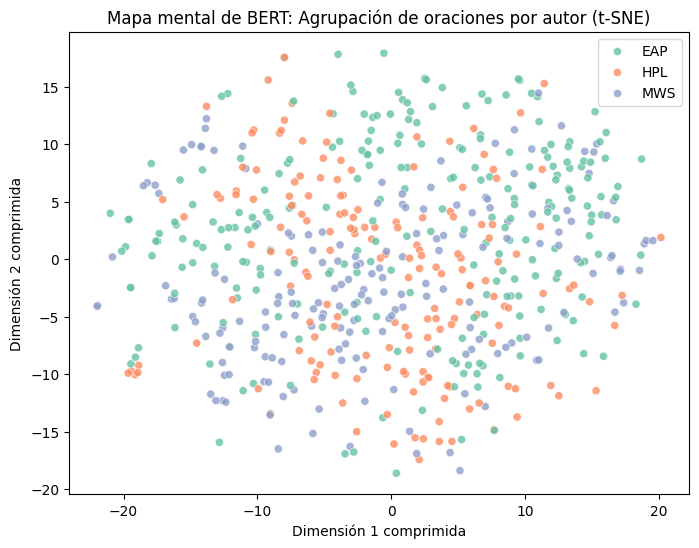

In [31]:
from sklearn.manifold import TSNE

# MAPA MENTAL DEL MODELO (t-SNE)
# Voy visualizar cómo la red neuronal agrupa los textos en su "cabeza"
# Como BERT piensa en 768 dimensiones, usaré t-SNE para comprimirlas a 2D (igual como hice con PCA).

modelo_bert.eval()

#tomo solo una muestra de 600 textos para que el computador no colapse calculando
textos_muestra = X_test[:600]
etiquetas_muestra = np.array(y_test_real[:len(textos_muestra)])

embeddings = []

with torch.no_grad():
    for i in range(0, len(textos_muestra), tamaño_batch):
        lote = textos_muestra[i:i + tamaño_batch]
        
        #el tokenizador traduce el lote de textos a números
        entradas = modelo_bert.tokenizador(
            lote, padding=True, truncation=True, max_length=128, return_tensors="pt"
        )
        entradas = {k: v.to(dispositivo) for k, v in entradas.items()}
        
        #pasa por los números por BERT
        salidas = modelo_bert.encoder(**entradas)
        oculto = salidas.last_hidden_state
        mascara = entradas["attention_mask"].unsqueeze(-1)
        
        #saca el "resumen matemático" definitivo (el embedding)
        embedding = (oculto * mascara).sum(1) / mascara.sum(1)
        embeddings.append(embedding.cpu().numpy())

#junta todos los mini-lotes en una sola lista gigante
embeddings = np.concatenate(embeddings, axis=0)

#llamar a t-SNE para hacer la compresión a 2 componentes (X e Y)
tsne = TSNE(n_components=2, random_state=42, init="pca")
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embeddings_2d[:, 0], 
    y=embeddings_2d[:, 1],
    hue=[nombres_clases[l] for l in etiquetas_muestra],
    palette="Set2", #colores bonitos 
    alpha=0.8, 
    s=35
)

plt.title("Mapa mental de BERT: Agrupación de oraciones por autor (t-SNE)")
plt.xlabel("Dimensión 1 comprimida")
plt.ylabel("Dimensión 2 comprimida")
plt.show()

Podemos apreciar que Bert no separó tan bien a los 3 autores, probablemente es porque al principio se vé que lo que más tiene peso son los nombres de los personajes más que las frases de los autores, por eso Nayve Bayes da mejor acurracy

In [32]:
#prueba rápida con textos nuevos
ejemplos = [
    "The old house stood silent, its stones whispering of things man was not meant to know.",
    "It was a dark and stormy night when the creature first opened its eyes.",
    "I could not help but feel an unshakable dread as the shadows crept along the wall.",
    "This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might make its circuit, and return to the point whence I set out, without being aware of the fact; so perfectly uniform seemed the wall.",
    "How lovely is spring As we looked from Windsor Terrace on the sixteen fertile counties spread beneath, speckled by happy cottages and wealthier towns, all looked as in former years, heart cheering and fair.",
]

modelo_bert.eval()
with torch.no_grad():
    logits = modelo_bert(ejemplos)
    predicciones = logits.argmax(dim=1).tolist()

#diccionario para traducir los números de vuelta a nombres
nombres_autores = {0: "EAP (Edgar Allan Poe)", 1: "HPL (H.P. Lovecraft)", 2: "MWS (Mary Shelley)"}

for texto, pred in zip(ejemplos, predicciones):
    autor = nombres_autores[pred]
    print(f"[{autor}] {texto}")

[HPL (H.P. Lovecraft)] The old house stood silent, its stones whispering of things man was not meant to know.
[HPL (H.P. Lovecraft)] It was a dark and stormy night when the creature first opened its eyes.
[HPL (H.P. Lovecraft)] I could not help but feel an unshakable dread as the shadows crept along the wall.
[EAP (Edgar Allan Poe)] This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might make its circuit, and return to the point whence I set out, without being aware of the fact; so perfectly uniform seemed the wall.
[MWS (Mary Shelley)] How lovely is spring As we looked from Windsor Terrace on the sixteen fertile counties spread beneath, speckled by happy cottages and wealthier towns, all looked as in former years, heart cheering and fair.


Acertó a todas :)